In [23]:
# CELL 1
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Prevent TF from instantly consuming all local GPU VRAM
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Configured {len(gpus)} GPU(s) for memory growth.")
    except RuntimeError as e:
        print(e)

# Define your local dataset path here (update this to match your folder structure)
DATASET_DIR = "./dataset-kaggle/train" # Assuming standard structure: train/0, train/1...
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

In [24]:
# CELL 2
def encode_ordinal(label):
    """
    Converts an integer KL grade (0-4) into a 4-node ordinal array.
    Example: 
    Grade 0 -> [0, 0, 0, 0]
    Grade 1 -> [1, 0, 0, 0]
    Grade 3 -> [1, 1, 1, 0]
    """
    ordinal_target = np.zeros(4, dtype=np.float32)
    if label > 0:
        ordinal_target[:label] = 1.0
    return ordinal_target

# Quick test to verify for your presentation
for i in range(5):
    print(f"KL Grade {i} -> Ordinal Vector: {encode_ordinal(i)}")

KL Grade 0 -> Ordinal Vector: [0. 0. 0. 0.]
KL Grade 1 -> Ordinal Vector: [1. 0. 0. 0.]
KL Grade 2 -> Ordinal Vector: [1. 1. 0. 0.]
KL Grade 3 -> Ordinal Vector: [1. 1. 1. 0.]
KL Grade 4 -> Ordinal Vector: [1. 1. 1. 1.]


In [25]:
# CELL 3 (UPDATED WITH SAMPLE WEIGHTS)
from sklearn.utils.class_weight import compute_class_weight

class KneeOsteoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=32, target_size=(224, 224), shuffle=True):
        super().__init__() # Fixed the Keras warning!
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)
            
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        # Calculate balanced weights for the dataset
        unique_classes = np.unique(self.labels)
        weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=self.labels)
        self.class_weight_dict = dict(zip(unique_classes, weights))
        print(f"Computed Class Weights: {self.class_weight_dict}")

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_paths = [self.image_paths[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        X = np.empty((len(batch_paths), *self.target_size, 3), dtype=np.float32)
        y = np.empty((len(batch_paths), 4), dtype=np.float32) 
        weights = np.empty((len(batch_paths),), dtype=np.float32) # New weight array

        for i, (path, label) in enumerate(zip(batch_paths, batch_labels)):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = self.clahe.apply(img)
            else:
                img = np.zeros(self.target_size, dtype=np.uint8)
                
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            img = cv2.resize(img, self.target_size)
            
            X[i] = img / 255.0
            y[i] = encode_ordinal(label)
            
            # Apply the calculated weight to this specific image
            weights[i] = self.class_weight_dict[label]

        # Generator now yields (Inputs, Targets, Sample_Weights)
        return X, y, weights

Total images found: 11556
Training images: 9244
Validation images: 2312
Computed Class Weights: {np.int64(0): np.float64(0.5055509980858627), np.int64(1): np.float64(1.10442054958184), np.int64(2): np.float64(0.7623917525773196), np.int64(3): np.float64(1.526672171758877), np.int64(4): np.float64(6.674368231046931)}
Computed Class Weights: {np.int64(0): np.float64(0.5053551912568306), np.int64(1): np.float64(1.10622009569378), np.int64(2): np.float64(0.7617792421746293), np.int64(3): np.float64(1.526072607260726), np.int64(4): np.float64(6.701449275362319)}


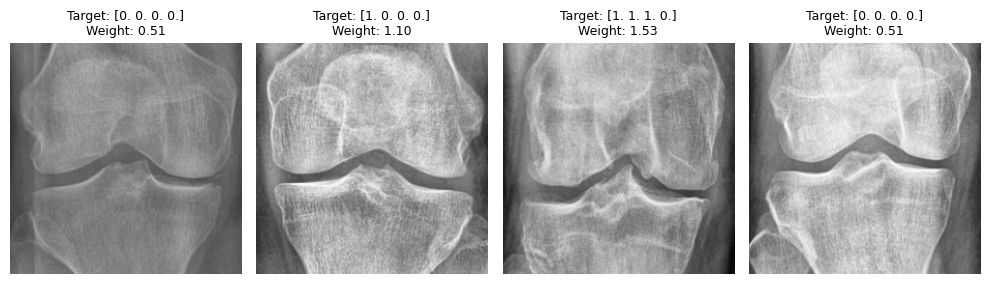

In [28]:
# CELL 4 (UPDATED to handle Weights)
import glob
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

all_image_paths = []
all_labels = []

for grade in range(5): 
    folder_path = os.path.join(DATASET_DIR, str(grade))
    images = []
    for ext in ('*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG'):
        images.extend(glob.glob(os.path.join(folder_path, ext)))
    all_image_paths.extend(images)
    all_labels.extend([grade] * len(images))

print(f"Total images found: {len(all_image_paths)}")

if len(all_image_paths) > 0:
    # 1. Split the data
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        all_image_paths, all_labels, 
        test_size=0.20, 
        random_state=42, 
        stratify=all_labels 
    )
    
    print(f"Training images: {len(train_paths)}")
    print(f"Validation images: {len(val_paths)}")

    # 2. Create generators
    train_gen = KneeOsteoDataGenerator(train_paths, train_labels, batch_size=BATCH_SIZE, target_size=IMG_SIZE)
    val_gen = KneeOsteoDataGenerator(val_paths, val_labels, batch_size=BATCH_SIZE, target_size=IMG_SIZE, shuffle=False)

    # 3. Visualize a batch (FIXED UNPACKING HERE)
    X_batch, y_batch, w_batch = train_gen[0] 
    
    plt.figure(figsize=(10, 5))
    num_to_show = min(4, len(X_batch)) 
    for i in range(num_to_show): 
        plt.subplot(1, num_to_show, i+1)
        plt.imshow(X_batch[i]) 
        # Added the weight to the title to prove to faculty it's working!
        plt.title(f"Target: {y_batch[i]}\nWeight: {w_batch[i]:.2f}", fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# CELL 5
def build_ordinal_model(input_shape=(224, 224, 3)):
    # Use EfficientNet as the feature extractor
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model for initial training
    base_model.trainable = False 

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x) # Prevent overfitting
    
    # THE ORDINAL HEAD: 4 Independent nodes, Sigmoid activation
    # Node 0: > Grade 0? | Node 1: > Grade 1? | Node 2: > Grade 2? | Node 3: > Grade 3?
    outputs = Dense(4, activation='sigmoid', name='ordinal_output')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

model = build_ordinal_model(input_shape=(*IMG_SIZE, 3))
model.summary()

In [32]:
# THE MASTER TRAINING CELL (Two-Phase Approach)
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

# 1. REBUILD CLEANLY
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False # PHASE 1: FREEZE THE SPINE

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
outputs = Dense(4, activation='sigmoid', name='ordinal_output')(x)
model = Model(inputs=base_model.input, outputs=outputs)

print("--- PHASE 1: WARMING UP THE ORDINAL HEAD ---")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Standard LR for new layers
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(name='bin_acc')]
)

# Train only the top layer for 3 epochs to align the random weights
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=3, 
    verbose=1
)

print("\n--- PHASE 2: DEEP FINE-TUNING ---")
# UNFREEZE THE SPINE
base_model.trainable = True 

# Recompile with a MICRO learning rate so we don't destroy the ImageNet weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(name='bin_acc')]
)

callbacks = [
    ModelCheckpoint("best_final_model.keras", save_best_only=True, monitor="val_loss", verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1), 
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss", verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15, 
    callbacks=callbacks
)

--- PHASE 1: WARMING UP THE ORDINAL HEAD ---
Epoch 1/3
578/578 ━━━━━━━━━━━━━━━━━━━━ 118s 198ms/step - bin_acc: 0.6886 - loss: 0.6011 - val_bin_acc: 0.7092 - val_loss: 0.5897
Epoch 2/3
578/578 ━━━━━━━━━━━━━━━━━━━━ 112s 194ms/step - bin_acc: 0.6901 - loss: 0.6016 - val_bin_acc: 0.5397 - val_loss: 0.6016
Epoch 3/3
578/578 ━━━━━━━━━━━━━━━━━━━━ 111s 191ms/step - bin_acc: 0.6839 - loss: 0.6095 - val_bin_acc: 0.7092 - val_loss: 0.6043

--- PHASE 2: DEEP FINE-TUNING ---
Epoch 1/15
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - bin_acc: 0.3808 - loss: 0.8190
Epoch 1: val_loss improved from inf to 0.64416, saving model to best_final_model.keras
578/578 ━━━━━━━━━━━━━━━━━━━━ 541s 897ms/step - bin_acc: 0.3810 - loss: 0.8188 - val_bin_acc: 0.6687 - val_loss: 0.6442 - learning_rate: 1.0000e-05
Epoch 2/15
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - bin_acc: 0.7544 - loss: 0.5076
Epoch 2: val_loss improved from 0.64416 to 0.50951, saving model to best_final_model.keras
578/578 ━━━━━━━━━━━━━━━━━━━━ 510s 

KeyboardInterrupt: 

In [17]:
# CELL 7: Fine-Tuning
print("Unfreezing the base model for fine-tuning...")

# 1. Unfreeze the base model
model.trainable = True 

# 2. Recompile with a VERY low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(name='bin_acc')]
)

# 3. Setup fine-tuning callbacks
ft_callbacks = [
    ModelCheckpoint("best_finetuned_knee_model.keras", save_best_only=True, monitor="val_loss", verbose=1),
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss", verbose=1)
]

# 4. Train again
print("Starting Fine-Tuning Phase...")
ft_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5, 
    callbacks=ft_callbacks
)

Unfreezing the base model for fine-tuning...
Starting Fine-Tuning Phase...
Epoch 1/5
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - bin_acc: 0.7472 - loss: 0.4824
Epoch 1: val_loss improved from inf to 0.48207, saving model to best_finetuned_knee_model.keras
578/578 ━━━━━━━━━━━━━━━━━━━━ 111s 186ms/step - bin_acc: 0.7472 - loss: 0.4824 - val_bin_acc: 0.7475 - val_loss: 0.4821
Epoch 2/5
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - bin_acc: 0.7432 - loss: 0.4850
Epoch 2: val_loss improved from 0.48207 to 0.48207, saving model to best_finetuned_knee_model.keras
578/578 ━━━━━━━━━━━━━━━━━━━━ 106s 184ms/step - bin_acc: 0.7432 - loss: 0.4850 - val_bin_acc: 0.7475 - val_loss: 0.4821
Epoch 3/5
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - bin_acc: 0.7473 - loss: 0.4805
Epoch 3: val_loss improved from 0.48207 to 0.48206, saving model to best_finetuned_knee_model.keras
578/578 ━━━━━━━━━━━━━━━━━━━━ 107s 185ms/step - bin_acc: 0.7473 - loss: 0.4805 - val_bin_acc: 0.7475 - val_loss: 0.4821
Epoch 4/5
578/

Targeting specific layer 'top_activation' for Grad-CAM feature extraction.


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_241']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Generating Explanation for: ./dataset-kaggle/train\2\9207458R.png


C:\Users\shrey\AppData\Local\Temp\ipykernel_19892\2403580177.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


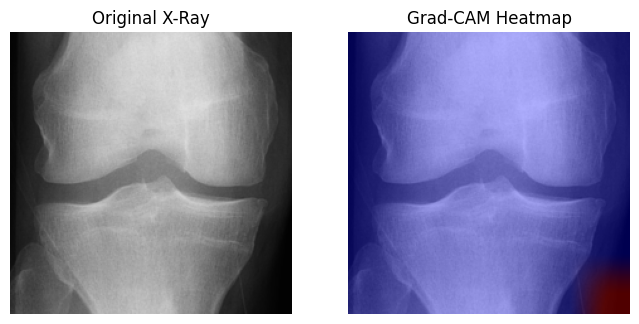

In [21]:
# CELL 8: Grad-CAM Visualization
import matplotlib.cm as cm

def get_img_array(img_path, size):
    # Reads, applies CLAHE (like our generator), and formats for the model
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, size)
    return np.expand_dims(img / 255.0, axis=0)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create a model that maps the input image to the activations of the last conv layer
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # Sum the predictions across the ordinal nodes
        loss = tf.reduce_sum(preds[0]) 

    # The gradient of the output neuron with respect to the output feature map
    grads = tape.gradient(loss, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    
    # Rescale heatmap to a range 0-255 and map to jet colormap
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Superimpose the heatmap on original image
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original X-Ray")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

last_conv_layer_name = None
for layer in reversed(model.layers):
    try:
        # Check if the layer's output has 4 dimensions (Batch, Height, Width, Channels)
        # This safely identifies conv layers without triggering AttributeErrors
        if len(layer.output.shape) == 4 and "input" not in layer.name:
            last_conv_layer_name = layer.name
            break
    except AttributeError:
        # Skip layers that don't explicitly define a shape attribute
        continue

if last_conv_layer_name is None:
    raise ValueError("Could not find a 4D convolutional layer. Check model summary.")

print(f"Targeting specific layer '{last_conv_layer_name}' for Grad-CAM feature extraction.")

# Test it on a random image from your validation set
sample_image_path = val_paths[5] 
img_array = get_img_array(sample_image_path, size=IMG_SIZE)

# Generate and display
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
print(f"Generating Explanation for: {sample_image_path}")
display_gradcam(sample_image_path, heatmap)